<a href="https://colab.research.google.com/github/Sneha8126/Python-Assignment/blob/main/Assisgnment_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Heart Disease"].value_counts()

,count
Heart Disease,
Absence,150
Presence,120


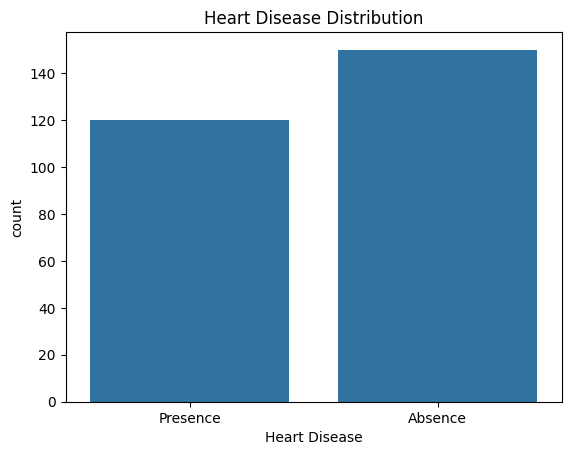

In [ ]:
sns.countplot(data=df, x="Heart Disease")
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence":1,
    "Absence":0
})

In [ ]:
df["Heart Disease"].value_counts()

,count
Heart Disease,
0,150
1,120


In [ ]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [ ]:
train_pred[:5]

array([0, 1, 0, 0, 1])

In [ ]:
y_train[:5]

,Heart Disease
78,0
121,1
27,0
198,0
218,0


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8518518518518519


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[24  6]
 [ 2 22]]


In [ ]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.7857142857142857

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.9166666666666666

In [ ]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[107  13]
 [ 19  77]]
Train Accuracfy :- 0.8518518518518519
Train Precision Score :- 0.8555555555555555
Train Recall Score :- 0.8020833333333334


In [ ]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[24  6]
 [ 2 22]]
Test Accuracy :- 0.8518518518518519
Test Precision Score :- 0.7857142857142857
Test Recall Score :- 0.9166666666666666


# Web Page

In [ ]:
import joblib

joblib.dump(model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
!pip install streamlit pyngrok

In [ ]:
!pip install streamlit pyngrok joblib

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

model = joblib.load("heart_model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(
    page_title="Heart Disease Prediction",
    page_icon="❤️"
)

st.title("❤️ Heart Disease Prediction")

age = st.number_input("Age",20,100)

sex = st.selectbox(
    "Sex",
    ["Female","Male"]
)

cp = st.selectbox(
    "Chest Pain Type",
    [1,2,3,4]
)

trestbps = st.number_input(
    "Resting Blood Pressure",
    80,
    220
)

chol = st.number_input(
    "Cholesterol",
    100,
    600
)

fbs = st.selectbox(
    "Fasting Blood Sugar",
    ["No","Yes"]
)

restecg = st.selectbox(
    "Rest ECG",
    [0,1,2]
)

thalach = st.number_input(
    "Maximum Heart Rate",
    60,
    220
)

exang = st.selectbox(
    "Exercise Angina",
    ["No","Yes"]
)

oldpeak = st.number_input(
    "Old Peak",
    0.0,
    10.0
)

slope = st.selectbox(
    "Slope",
    [1,2,3]
)

ca = st.selectbox(
    "Major Vessels",
    [0,1,2,3]
)

thal = st.selectbox(
    "Thal",
    [3,6,7]
)

sex = 1 if sex=="Male" else 0
fbs = 1 if fbs=="Yes" else 0
exang = 1 if exang=="Yes" else 0

if st.button("Predict"):

    data = np.array([[

        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal

    ]])

    data = scaler.transform(data)

    prediction = model.predict(data)[0]

    probability = model.predict_proba(data)[0][1]

    if prediction==1:

        st.error("❤️ Heart Disease Detected")

        st.write(
            f"Probability : {probability*100:.2f}%"
        )

    else:

        st.success("💚 No Heart Disease")

        st.write(
            f"Probability : {(1-probability)*100:.2f}%"
        )

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3GRH7THfdty76EPcm1ZGthXetVQ_6imJEkJaJNkCXR9pYCfa7")

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://splendor-pecan-thousand.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!cat /content/log.txt



2026-07-13 07:23:49.403 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://35.185.60.61:8502



In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.7.1) ...
Setting up cloudflared (2026.7.1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!cloudflared tunnel --url http://localhost:8502 > tunnel.log 2>&1 &

In [ ]:
!cat tunnel.log

2026-07-13T07:29:56Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-13T07:29:56Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-13T07:30:00Z INF +--------------------------------------------------------------------------------------------+
2026-07-13T07:30:00Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-13T07:30:00Z INF |  https://inquiries-leo-permit-nine.trycloudflare.com  

# D-Tree Implementation

In [ ]:
# D-Tree Implementation
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
train_pred = dt.predict(X_train)

test_pred = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

In [ ]:
print("Train Confusion Matrix:\n",confusion_matrix(y_train,train_pred))

print("Train Accuracy :",accuracy_score(y_train,train_pred))

print("Train Precision :",precision_score(y_train,train_pred))

print("Train Recall :",recall_score(y_train,train_pred))

print("Train F1 Score :",f1_score(y_train,train_pred))

Train Confusion Matrix:
 [[120   0]
 [  0  96]]
Train Accuracy : 1.0
Train Precision : 1.0
Train Recall : 1.0
Train F1 Score : 1.0


In [ ]:
print("Test Confusion Matrix:\n",confusion_matrix(y_test,test_pred))

print("Test Accuracy :",accuracy_score(y_test,test_pred))

print("Test Precision :",precision_score(y_test,test_pred))

print("Test Recall :",recall_score(y_test,test_pred))

print("Test F1 Score :",f1_score(y_test,test_pred))

Test Confusion Matrix:
 [[23  7]
 [ 4 20]]
Test Accuracy : 0.7962962962962963
Test Precision : 0.7407407407407407
Test Recall : 0.8333333333333334
Test F1 Score : 0.7843137254901961
